In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

folder_path = "../plotting_data/rsds_spatial"

# List all .npy files
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

# Load all files into a dictionary
data_solar = {}
file_names = []
for i in range(len(npy_files)):
    f = npy_files[i]
    file_path = os.path.join(folder_path, f)
    data_solar[i] = np.load(file_path)
    file_names.append(f)

In [3]:
folder_path = "../plotting_data/wind_spatial"

# List all .npy files
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

# Load all files into a dictionary
data_wind = {}
file_names = []
for i in range(len(npy_files)):
    f = npy_files[i]
    file_path = os.path.join(folder_path, f)
    data_wind[i] = np.load(file_path)
    file_names.append(f)

Indices from 0067 for wind 
Top 15 indices correlation: [10 20  3 23 14 27 25 26 28 29  8  5  7  6  9]
Top 15 indices mae: [28 26 29 25 27  7 10  9  5  6  8 17 20 19  2]

0067 for solar
Top 15 indices correlation: [28 21 30 27 23 26 12 24 14 22 25 13 29 11  8]
Bottom 15 indices mae: [ 0  2  3 22 24 23  4  1 19 15 20 21 17 16  8]

In [4]:
wind_mae = [28, 26, 29, 25, 27, 7, 10, 9, 5, 6, 8, 17, 20, 19, 2]
wind_corr = [10, 20, 3, 23, 14, 27, 25, 26, 28, 29, 8, 5, 7, 6, 9]
solar_mae = [0, 2, 3, 22, 24, 23, 4, 1, 19, 15, 20, 21, 17, 16, 8]
solar_corr = [28, 21, 30, 27, 23, 26, 12, 24, 14, 22, 25, 13, 29, 11, 8]

solar_data = data_solar[0]
wind_data = data_wind[0]

selected_files_solar = [
    "marginal_average_seasonal_hourly.npy",
    "marginal_var_seasonal.npy",
    "spatiotemporal_below_percentile_seasonal.npy",
    "spatiotemporal_above_percentile_seasonal.npy",
]

selected_files_wind = [
    "marginal_average_seasonal_hourly.npy",
    "marginal_var_seasonal.npy",
    "spatiotemporal_below_percentile_seasonal.npy",
    "spatiotemporal_above_percentile_seasonal.npy",
]

In [5]:
solar_data_mae = solar_data[solar_mae]
solar_data_corr = solar_data[solar_corr]
wind_data_mae = wind_data[wind_mae]
wind_data_corr = wind_data[wind_corr]

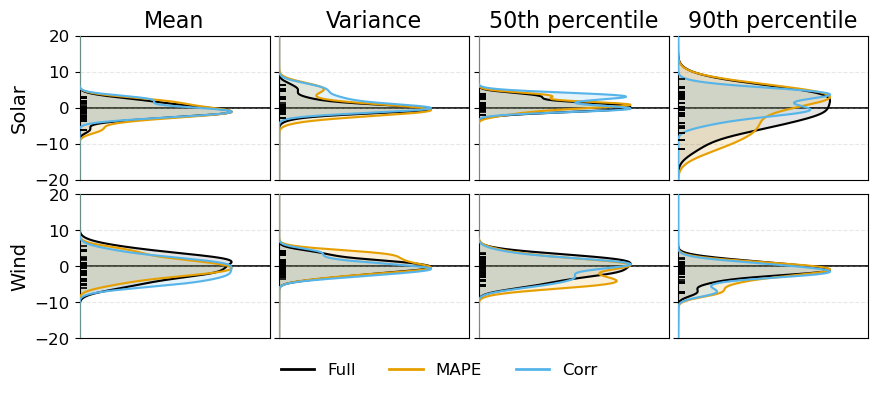

In [6]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

four_names = ["Mean", "Variance", "50th percentile", "90th percentile"]

plot_structure = {
    "Solar": {
        "dict": data_solar,
        "files": selected_files_solar,
        "mae_idx": solar_mae,
        "corr_idx": solar_corr,
    },
    "Wind": {
        "dict": data_wind,
        "files": selected_files_wind,
        "mae_idx": wind_mae,
        "corr_idx": wind_corr,
    },
}

fig, axes = plt.subplots(2, 4, figsize=(9, 4), sharey="row")

legend_elements = [
    Line2D([0], [0], color="black", lw=2, label="Full"),
    Line2D([0], [0], color="#E69F00", lw=2, label="MAPE"),
    Line2D([0], [0], color="#56B4E9", lw=2, label="Corr"),
]

for row_idx, (row_name, cfg) in enumerate(plot_structure.items()):
    for col_idx, file_name in enumerate(cfg["files"]):
        ax = axes[row_idx, col_idx]
        ax.axhline(0, color="black", lw=1.2, linestyle="-", zorder=1)

        idx_list = [j for j, n in enumerate(file_names) if n == file_name]
        if not idx_list:
            continue
        score = idx_list[0]
        ds = np.asarray(cfg["dict"][score])

        if ds.ndim == 4:
            ds = ds[:, col_idx, :, :]
        # Mean per model
        model_means = np.nanmean(ds, axis=(-2, -1))

        subsets = [
            ("Full", np.arange(len(model_means)), "black", 0.1),
            ("MAPE", cfg["mae_idx"], "#E69F00", 0.15),
            ("Corr", cfg["corr_idx"], "#56B4E9", 0.15),
        ]

        y_grid = np.linspace(-20, 30, 500)

        for label, indices, color, alpha_f in subsets:
            group_vals = model_means[indices]
            group_vals = group_vals[np.isfinite(group_vals)]

            if len(group_vals) > 1:
                try:
                    kde = gaussian_kde(group_vals, bw_method=0.5)
                    x_vals = kde.evaluate(y_grid)
                    x_vals = x_vals / np.max(x_vals) * 0.8

                    ax.plot(x_vals, y_grid, color=color, lw=1.5, label=label, zorder=3)
                    ax.fill_betweenx(
                        y_grid, 0, x_vals, color=color, alpha=alpha_f, zorder=2
                    )

                    ax.plot(
                        np.zeros_like(group_vals),
                        group_vals,
                        "_",
                        color="black",
                        markersize=10,
                        markeredgewidth=1.2,
                        zorder=4,
                    )
                except:
                    continue

        if row_idx == 0:
            ax.set_title(four_names[col_idx])
        if col_idx == 0:
            ax.set_ylabel(f"{row_name}")

        ax.set_xticks([])
        ax.set_xlim(0, 1)
        ax.set_ylim(-20, 20)
        ax.grid(axis="y", alpha=0.3, linestyle="--", zorder=0)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.01),
    frameon=False,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.savefig(
    "../plot/0068_changes_average.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()